
# ML Forecast Notebook (MEPA-Optimized)

Notebook ini mengeksekusi `plan_machinelearning.md` untuk membuat prediksi agregat bulanan:

- `Claim_Frequency`
- `Claim_Severity`
- `Total_Claim`

Horizon: **Agustus - Desember 2025** (5 bulan, total 15 nilai output).

Metrik utama: **MEPA** (Mean Error Percentage Absolute), target: **< 5**.


In [1]:

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset"
OUT_SUBMISSION = BASE_DIR / "submission_mepa.csv"
OUT_DETAILS = BASE_DIR / "forecast_details_mepa.json"

FORECAST_HORIZON = 5
FORECAST_MONTHS = pd.date_range("2025-08-01", periods=FORECAST_HORIZON, freq="MS")

print("BASE_DIR:", BASE_DIR)
print("Forecast months:", [d.strftime("%Y-%m") for d in FORECAST_MONTHS])


BASE_DIR: /home/data/kuliah/EDA/mcfitb
Forecast months: ['2025-08', '2025-09', '2025-10', '2025-11', '2025-12']


## 1) Utility Functions

In [2]:

def mepa(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / den)) * 100)


def mdape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.maximum(np.abs(y_true), eps)
    return float(np.median(np.abs((y_true - y_pred) / den)) * 100)


def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    true_dir = np.diff(y_true) > 0
    pred_dir = np.diff(y_pred) > 0
    return float(np.mean(true_dir == pred_dir) * 100)


def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MEPA": mepa(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MdAPE": mdape(y_true, y_pred),
        "Directional_Accuracy": directional_accuracy(y_true, y_pred),
    }


def parse_indo_rate_csv(path, value_col):
    fx = pd.read_csv(path)
    fx["Tanggal"] = pd.to_datetime(fx["Tanggal"], format="%d/%m/%Y", errors="coerce")
    fx[value_col] = (
        fx["Terakhir"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )
    fx = fx[["Tanggal", value_col]].dropna().sort_values("Tanggal")
    monthly_fx = fx.set_index("Tanggal").resample("MS")[value_col].mean().to_frame()
    return monthly_fx


## 2) Load and Prepare Data

In [3]:

def load_clean_claims(path):
    df = pd.read_csv(path)

    # Cleaning mengikuti plan
    df = df.drop_duplicates(
        subset=["Nomor Polis", "Tanggal Pasien Masuk RS", "Nominal Klaim Yang Disetujui"],
        keep="first",
    )
    df["Inpatient/Outpatient"] = df["Inpatient/Outpatient"].fillna("UNKNOWN")
    df["Lokasi RS"] = df["Lokasi RS"].fillna("Indonesia")
    df = df.dropna(subset=["ICD Diagnosis"])

    # Type conversions
    df["Bulan"] = pd.to_datetime(df["Bulan"], errors="coerce")
    df = df.dropna(subset=["Bulan"])

    return df


def build_monthly_dataset(df):
    monthly_core = (
        df.groupby("Bulan")
        .agg(
            Claim_Frequency=("Claim ID", "count"),
            Claim_Severity=("Nominal Klaim Yang Disetujui", "mean"),
            Total_Claim=("Nominal Klaim Yang Disetujui", "sum"),
        )
        .sort_index()
        .asfreq("MS")
    )

    monthly_exog = (
        df.groupby("Bulan")
        .agg(
            pct_age_60plus=("Usia", lambda x: (x >= 60).mean()),
            avg_age=("Usia", "mean"),
            pct_male=("Gender", lambda x: (x == "M").mean()),
            pct_cancer=("ICD_Group", lambda x: (x == "Neoplasma/Kanker").mean()),
            pct_cardio=("ICD_Group", lambda x: (x == "Kardiovaskular").mean()),
            pct_renal=("ICD_Group", lambda x: (x == "Genitourinari").mean()),
            pct_overseas=("Lokasi RS", lambda x: (x != "Indonesia").mean()),
            pct_singapore=("Lokasi RS", lambda x: (x == "Singapore").mean()),
            pct_inpatient=("Inpatient/Outpatient", lambda x: (x == "IP").mean()),
            pct_plan_m002=("Plan Code", lambda x: (x == "M-002").mean()),
            median_nominal=("Nominal Klaim Yang Disetujui", "median"),
            std_nominal=("Nominal Klaim Yang Disetujui", "std"),
            pct_outlier=("Nominal Klaim Yang Disetujui", lambda x: (x > 124_375_517).mean()),
            unique_polis=("Nomor Polis", "nunique"),
            avg_claims_per_polis=("Nomor Polis", lambda x: len(x) / max(x.nunique(), 1)),
        )
        .sort_index()
        .asfreq("MS")
    )

    monthly = monthly_core.join(monthly_exog, how="left")
    return monthly


claims = load_clean_claims(DATA_DIR / "Data_Klaim_Enriched.csv")
monthly = build_monthly_dataset(claims)

fx_myr = parse_indo_rate_csv(DATA_DIR / "Data Historis MYR_IDR.csv", "Avg_Kurs_MYR")
fx_sgd = parse_indo_rate_csv(DATA_DIR / "Data Historis SGD_IDR.csv", "Avg_Kurs_SGD")

monthly = monthly.join(fx_myr, how="left").join(fx_sgd, how="left")
monthly[["Avg_Kurs_MYR", "Avg_Kurs_SGD"]] = monthly[["Avg_Kurs_MYR", "Avg_Kurs_SGD"]].ffill().bfill()
monthly["MYR_change_pct"] = monthly["Avg_Kurs_MYR"].pct_change().fillna(0) * 100
monthly["SGD_change_pct"] = monthly["Avg_Kurs_SGD"].pct_change().fillna(0) * 100

monthly["log_Severity"] = np.log1p(monthly["Claim_Severity"])
monthly["log_Total"] = np.log1p(monthly["Total_Claim"])

print("Monthly shape:", monthly.shape)
print("Range:", monthly.index.min().date(), "to", monthly.index.max().date())
monthly[["Claim_Frequency", "Claim_Severity", "Total_Claim", "Avg_Kurs_MYR", "Avg_Kurs_SGD"]].head()


Monthly shape: (19, 24)
Range: 2024-01-01 to 2025-07-01


,Claim_Frequency,Claim_Severity,Total_Claim,Avg_Kurs_MYR,Avg_Kurs_SGD
Bulan,,,,,
2024-01-01,296,"67,526,085.2405","19,987,721,231.1931","3,322.5800","11,684.2683"
2024-02-01,208,"66,632,910.8659","13,859,645,460.1035","3,278.8143","11,628.5610"
2024-03-01,278,"51,479,345.6559","14,311,258,092.3494","3,327.0476","11,708.2490"
2024-04-01,236,"48,463,787.1972","11,437,453,778.5500","3,363.0227","11,814.2764"
2024-05-01,262,"46,543,193.2083","12,194,316,620.5700","3,404.1991","11,888.5591"


## 3) Expanding-Window CV and Model Candidates

In [4]:

def fit_predict_one_step(train_series, model_name, order=None, use_log=False, exog_train=None, exog_next=None):
    y = np.log1p(train_series) if use_log else train_series

    if model_name == "naive":
        pred = float(train_series.iloc[-1])
        return max(pred, 0.0)

    if model_name == "ets":
        model = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal=None).fit(optimized=True)
        pred = float(model.forecast(1).iloc[0])
        pred = np.expm1(pred) if use_log else pred
        return max(pred, 0.0)

    if model_name == "sarimax":
        kwargs = dict(
            order=order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        if exog_train is not None:
            model = SARIMAX(y, exog=exog_train, **kwargs).fit(disp=False)
            pred = float(model.forecast(1, exog=exog_next).iloc[0])
        else:
            model = SARIMAX(y, **kwargs).fit(disp=False)
            pred = float(model.forecast(1).iloc[0])

        pred = np.expm1(pred) if use_log else pred
        return max(pred, 0.0)

    raise ValueError(f"Unknown model_name: {model_name}")


def expanding_window_cv(
    series,
    model_name,
    order=None,
    use_log=False,
    n_test=7,
    min_train=12,
    exog_df=None,
):
    y_true = []
    y_pred = []

    for i in range(n_test):
        train_end = min_train + i
        train = series.iloc[:train_end]
        test = float(series.iloc[train_end])

        exog_train = None
        exog_next = None
        if exog_df is not None:
            exog_train = exog_df.iloc[:train_end]
            exog_next = exog_df.iloc[train_end : train_end + 1]

        try:
            pred = fit_predict_one_step(
                train_series=train,
                model_name=model_name,
                order=order,
                use_log=use_log,
                exog_train=exog_train,
                exog_next=exog_next,
            )
        except Exception:
            pred = float(train.iloc[-1])

        y_true.append(test)
        y_pred.append(float(max(pred, 0.0)))

    metrics = evaluate_metrics(y_true, y_pred)
    return metrics, np.array(y_true), np.array(y_pred)


EXOG_COLS = ["pct_cancer", "pct_overseas", "pct_age_60plus", "Avg_Kurs_SGD", "Avg_Kurs_MYR"]
exog_hist = monthly[EXOG_COLS].copy().ffill().bfill()

candidate_orders = [
    (0, 0, 2),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 1),
    (2, 1, 1),
]


def evaluate_target(series, target_name, use_log):
    records = []

    # Baselines
    for model_name in ["naive", "ets"]:
        met, y, p = expanding_window_cv(
            series=series,
            model_name=model_name,
            use_log=use_log,
            n_test=7,
            min_train=12,
            exog_df=None,
        )
        records.append({"target": target_name, "model": model_name, "order": None, **met, "y_true": y, "y_pred": p})

    # SARIMAX non-exog
    for order in candidate_orders:
        met, y, p = expanding_window_cv(
            series=series,
            model_name="sarimax",
            order=order,
            use_log=use_log,
            n_test=7,
            min_train=12,
            exog_df=None,
        )
        records.append({"target": target_name, "model": "sarimax", "order": order, **met, "y_true": y, "y_pred": p})

    # SARIMAX exog
    for order in candidate_orders:
        met, y, p = expanding_window_cv(
            series=series,
            model_name="sarimax",
            order=order,
            use_log=use_log,
            n_test=7,
            min_train=12,
            exog_df=exog_hist,
        )
        records.append({"target": target_name, "model": "sarimax_exog", "order": order, **met, "y_true": y, "y_pred": p})

    result_df = pd.DataFrame(records).sort_values("MEPA").reset_index(drop=True)
    return result_df


eval_freq = evaluate_target(monthly["Claim_Frequency"], "Claim_Frequency", use_log=False)
eval_sev = evaluate_target(monthly["Claim_Severity"], "Claim_Severity", use_log=True)
eval_total = evaluate_target(monthly["Total_Claim"], "Total_Claim", use_log=True)

print("Top models by MEPA (Frequency)")
display(eval_freq[["model", "order", "MEPA", "MAE", "RMSE", "MdAPE", "Directional_Accuracy"]].head(5))

print("Top models by MEPA (Severity)")
display(eval_sev[["model", "order", "MEPA", "MAE", "RMSE", "MdAPE", "Directional_Accuracy"]].head(5))

print("Top models by MEPA (Total)")
display(eval_total[["model", "order", "MEPA", "MAE", "RMSE", "MdAPE", "Directional_Accuracy"]].head(5))

best_freq = eval_freq.iloc[0]
best_sev = eval_sev.iloc[0]
best_total = eval_total.iloc[0]

summary_best = pd.DataFrame([
    {
        "target": "Claim_Frequency",
        "best_model": best_freq["model"],
        "best_order": best_freq["order"],
        "MEPA": best_freq["MEPA"],
    },
    {
        "target": "Claim_Severity",
        "best_model": best_sev["model"],
        "best_order": best_sev["order"],
        "MEPA": best_sev["MEPA"],
    },
    {
        "target": "Total_Claim",
        "best_model": best_total["model"],
        "best_order": best_total["order"],
        "MEPA": best_total["MEPA"],
    },
])

display(summary_best)

for _, row in summary_best.iterrows():
    status = "OK (<5)" if row["MEPA"] < 5 else "Needs Improvement (>=5)"
    print(f"{row['target']}: MEPA={row['MEPA']:.3f} -> {status}")


Top models by MEPA (Frequency)


,model,order,MEPA,MAE,RMSE,MdAPE,Directional_Accuracy
0,ets,None,7.1658,16.5722,19.6638,5.9914,16.6667
1,sarimax,"(1, 1, 1)",7.6792,17.6040,22.3334,3.6406,50.0000
2,sarimax,"(2, 1, 1)",7.7841,17.8713,22.5303,3.6521,66.6667
3,sarimax,"(0, 0, 2)",7.7998,17.7255,19.9354,7.0692,66.6667
4,sarimax,"(0, 1, 1)",7.9100,18.1979,21.8912,4.5792,16.6667


Top models by MEPA (Severity)


,model,order,MEPA,MAE,RMSE,MdAPE,Directional_Accuracy
0,ets,None,10.2776,"6,220,418.1393","9,172,943.6420",7.9430,0.0000
1,sarimax,"(1, 1, 1)",11.0126,"6,600,175.4577","9,945,844.5663",7.2525,33.3333
2,sarimax,"(0, 1, 1)",11.7886,"7,170,265.2064","10,963,014.3488",7.4207,16.6667
3,sarimax,"(1, 0, 1)",12.5976,"7,473,774.9061","9,850,842.7658",7.7352,16.6667
4,sarimax_exog,"(0, 1, 1)",15.1965,"9,074,964.0460","12,956,399.6414",8.7975,33.3333


Top models by MEPA (Total)


,model,order,MEPA,MAE,RMSE,MdAPE,Directional_Accuracy
0,sarimax,"(0, 0, 2)",12.6702,"1,652,951,098.1982","2,223,647,029.5756",6.1084,83.3333
1,sarimax,"(1, 0, 1)",13.9965,"1,852,038,602.3987","2,587,801,380.0843",6.2606,66.6667
2,ets,None,14.2987,"1,938,784,388.2622","2,597,822,732.9939",10.0755,16.6667
3,sarimax_exog,"(1, 1, 1)",14.3197,"1,976,155,480.1887","2,597,569,863.9268",13.3071,66.6667
4,sarimax,"(0, 1, 1)",15.2380,"2,017,172,964.8792","2,717,270,582.9538",8.0234,16.6667


,target,best_model,best_order,MEPA
0,Claim_Frequency,ets,None,7.1658
1,Claim_Severity,ets,None,10.2776
2,Total_Claim,sarimax,"(0, 0, 2)",12.6702


Claim_Frequency: MEPA=7.166 -> Needs Improvement (>=5)
Claim_Severity: MEPA=10.278 -> Needs Improvement (>=5)
Total_Claim: MEPA=12.670 -> Needs Improvement (>=5)


## 4) Fit Final Models and Forecast Aug-Dec 2025

In [5]:

def make_future_exog(monthly_df, exog_cols, horizon, forecast_months):
    hist = monthly_df[exog_cols].copy()

    # Komposisi portfolio: asumsi rata-rata 3 bulan terakhir
    composition_cols = [c for c in exog_cols if c.startswith("pct_")]
    comp_values = hist[composition_cols].tail(3).mean()

    # Kurs: pakai data aktual jika tersedia pada file historis kurs
    future_exog = pd.DataFrame(index=forecast_months, columns=exog_cols, dtype=float)

    for col in composition_cols:
        future_exog[col] = comp_values[col]

    for col in ["Avg_Kurs_SGD", "Avg_Kurs_MYR"]:
        if col in hist.columns:
            # gunakan nilai per bulan yang tersedia, fallback ke nilai terakhir
            for m in forecast_months:
                if m in hist.index and pd.notna(hist.loc[m, col]):
                    future_exog.loc[m, col] = hist.loc[m, col]
                else:
                    future_exog.loc[m, col] = hist[col].dropna().iloc[-1]

    future_exog = future_exog.ffill().bfill()
    return future_exog


future_exog = make_future_exog(monthly, EXOG_COLS, FORECAST_HORIZON, FORECAST_MONTHS)
print("Future exogenous assumptions")
display(future_exog)


def fit_full_and_forecast(series, model_name, order, use_log, exog_train=None, exog_future=None):
    y = np.log1p(series) if use_log else series

    if model_name == "naive":
        pred = np.repeat(float(series.iloc[-1]), FORECAST_HORIZON)
        return np.maximum(pred, 0.0), None

    if model_name == "ets":
        m = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal=None).fit(optimized=True)
        pred = m.forecast(FORECAST_HORIZON).values
        pred = np.expm1(pred) if use_log else pred
        return np.maximum(pred, 0.0), m

    if model_name == "sarimax":
        m = SARIMAX(
            y,
            order=order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        fc = m.get_forecast(steps=FORECAST_HORIZON)
        pred = fc.predicted_mean.values
        pred = np.expm1(pred) if use_log else pred
        return np.maximum(pred, 0.0), (m, fc)

    if model_name == "sarimax_exog":
        m = SARIMAX(
            y,
            exog=exog_train,
            order=order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        fc = m.get_forecast(steps=FORECAST_HORIZON, exog=exog_future)
        pred = fc.predicted_mean.values
        pred = np.expm1(pred) if use_log else pred
        return np.maximum(pred, 0.0), (m, fc)

    raise ValueError(f"Unknown model {model_name}")


# Forecast per target
freq_pred, freq_obj = fit_full_and_forecast(
    series=monthly["Claim_Frequency"],
    model_name=best_freq["model"],
    order=best_freq["order"],
    use_log=False,
    exog_train=exog_hist if best_freq["model"] == "sarimax_exog" else None,
    exog_future=future_exog if best_freq["model"] == "sarimax_exog" else None,
)
freq_pred = np.round(freq_pred).astype(int)

sev_pred, sev_obj = fit_full_and_forecast(
    series=monthly["Claim_Severity"],
    model_name=best_sev["model"],
    order=best_sev["order"],
    use_log=True,
    exog_train=exog_hist if best_sev["model"] == "sarimax_exog" else None,
    exog_future=future_exog if best_sev["model"] == "sarimax_exog" else None,
)

# Derived total = freq x severity
total_derived = freq_pred * sev_pred

# Direct total
total_direct, total_obj = fit_full_and_forecast(
    series=monthly["Total_Claim"],
    model_name=best_total["model"],
    order=best_total["order"],
    use_log=True,
    exog_train=exog_hist if best_total["model"] == "sarimax_exog" else None,
    exog_future=future_exog if best_total["model"] == "sarimax_exog" else None,
)

# Alpha tuning dari CV untuk blend direct vs derived
y_cv = best_total["y_true"]
p_direct_cv = best_total["y_pred"]
p_derived_cv = np.array(best_freq["y_pred"]) * np.array(best_sev["y_pred"])

alphas = np.linspace(0, 1, 21)
alpha_scores = []
for a in alphas:
    p = a * p_direct_cv + (1 - a) * p_derived_cv
    alpha_scores.append((a, mepa(y_cv, p)))

alpha_opt, alpha_mepa = sorted(alpha_scores, key=lambda x: x[1])[0]

total_final = alpha_opt * total_direct + (1 - alpha_opt) * total_derived

forecast_df = pd.DataFrame({
    "Bulan": FORECAST_MONTHS,
    "Claim_Frequency": freq_pred,
    "Claim_Severity": sev_pred,
    "Total_Claim_Derived": total_derived,
    "Total_Claim_Direct": total_direct,
    "Total_Claim_Final": total_final,
})

print(f"Optimal alpha for Total blend: {alpha_opt:.2f} (CV MEPA={alpha_mepa:.3f})")
display(forecast_df)


Future exogenous assumptions


,pct_cancer,pct_overseas,pct_age_60plus,Avg_Kurs_SGD,Avg_Kurs_MYR
2025-08-01,0.1625,0.3262,0.5392,"12,699.6143","3,842.7404"
2025-09-01,0.1625,0.3262,0.5392,"12,699.6143","3,842.7404"
2025-10-01,0.1625,0.3262,0.5392,"12,699.6143","3,842.7404"
2025-11-01,0.1625,0.3262,0.5392,"12,699.6143","3,842.7404"
2025-12-01,0.1625,0.3262,0.5392,"12,699.6143","3,842.7404"


Optimal alpha for Total blend: 1.00 (CV MEPA=12.670)


,Bulan,Claim_Frequency,Claim_Severity,Total_Claim_Derived,Total_Claim_Direct,Total_Claim_Final
0,2025-08-01,236,"52,881,322.6976","12,479,992,156.6255","12,462,316,489.4982","12,462,316,489.4982"
1,2025-09-01,236,"52,860,023.6693","12,474,965,585.9463","12,588,511,344.6934","12,588,511,344.6934"
2,2025-10-01,236,"52,842,990.6234","12,470,945,787.1206","12,806,742,031.5047","12,806,742,031.5047"
3,2025-11-01,235,"52,829,368.1385","12,414,901,512.5553","12,806,742,031.5047","12,806,742,031.5047"
4,2025-12-01,235,"52,818,472.6792","12,412,341,079.6023","12,806,742,031.5047","12,806,742,031.5047"


## 5) Confidence Interval and 15-Value Submission

In [6]:

def build_ci_from_cv(pred_future, y_true_cv, y_pred_cv):
    # CI berbasis distribusi APE CV (robust jika model bukan SARIMAX)
    ape = np.abs((np.asarray(y_true_cv) - np.asarray(y_pred_cv)) / np.maximum(np.abs(y_true_cv), 1e-9))
    q80 = np.quantile(ape, 0.80)
    q95 = np.quantile(ape, 0.95)

    pred_future = np.asarray(pred_future, dtype=float)
    ci80_low = np.maximum(pred_future * (1 - q80), 0.0)
    ci80_high = pred_future * (1 + q80)
    ci95_low = np.maximum(pred_future * (1 - q95), 0.0)
    ci95_high = pred_future * (1 + q95)

    return (
        np.column_stack([ci80_low, ci80_high]),
        np.column_stack([ci95_low, ci95_high]),
    )


freq_ci80, freq_ci95 = build_ci_from_cv(freq_pred, best_freq["y_true"], best_freq["y_pred"])
sev_ci80, sev_ci95 = build_ci_from_cv(sev_pred, best_sev["y_true"], best_sev["y_pred"])
tot_ci80, tot_ci95 = build_ci_from_cv(total_final, best_total["y_true"], best_total["y_pred"])

# Build submission (15 rows)
month_labels = [d.strftime("%Y_%m") for d in FORECAST_MONTHS]
rows = []
for i, label in enumerate(month_labels):
    rows.append({"id": f"{label}_Claim_Frequency", "value": float(freq_pred[i])})
    rows.append({"id": f"{label}_Claim_Severity", "value": float(sev_pred[i])})
    rows.append({"id": f"{label}_Total_Claim", "value": float(total_final[i])})

submission = pd.DataFrame(rows)
submission.to_csv(OUT_SUBMISSION, index=False)

details = {
    "forecast_months": [d.strftime("%Y-%m") for d in FORECAST_MONTHS],
    "best_models": {
        "Claim_Frequency": {"model": str(best_freq["model"]), "order": str(best_freq["order"]), "MEPA": float(best_freq["MEPA"])},
        "Claim_Severity": {"model": str(best_sev["model"]), "order": str(best_sev["order"]), "MEPA": float(best_sev["MEPA"])},
        "Total_Claim": {"model": str(best_total["model"]), "order": str(best_total["order"]), "MEPA": float(best_total["MEPA"])},
    },
    "blend": {"alpha_opt": float(alpha_opt), "cv_mepa": float(alpha_mepa)},
    "forecast": forecast_df.assign(Bulan=forecast_df["Bulan"].dt.strftime("%Y-%m")).to_dict(orient="records"),
    "confidence_intervals": {
        "freq_ci80": freq_ci80.tolist(),
        "freq_ci95": freq_ci95.tolist(),
        "sev_ci80": sev_ci80.tolist(),
        "sev_ci95": sev_ci95.tolist(),
        "total_ci80": tot_ci80.tolist(),
        "total_ci95": tot_ci95.tolist(),
    },
}

with open(OUT_DETAILS, "w", encoding="utf-8") as f:
    json.dump(details, f, indent=2)

print("Saved:", OUT_SUBMISSION)
print("Saved:", OUT_DETAILS)
display(submission)


Saved: /home/data/kuliah/EDA/mcfitb/submission_mepa.csv
Saved: /home/data/kuliah/EDA/mcfitb/forecast_details_mepa.json


,id,value
0,2025_08_Claim_Frequency,236.0000
1,2025_08_Claim_Severity,"52,881,322.6976"
2,2025_08_Total_Claim,"12,462,316,489.4982"
3,2025_09_Claim_Frequency,236.0000
4,2025_09_Claim_Severity,"52,860,023.6693"
5,2025_09_Total_Claim,"12,588,511,344.6934"
6,2025_10_Claim_Frequency,236.0000
7,2025_10_Claim_Severity,"52,842,990.6234"
8,2025_10_Total_Claim,"12,806,742,031.5047"
9,2025_11_Claim_Frequency,235.0000


## 6) Visualization

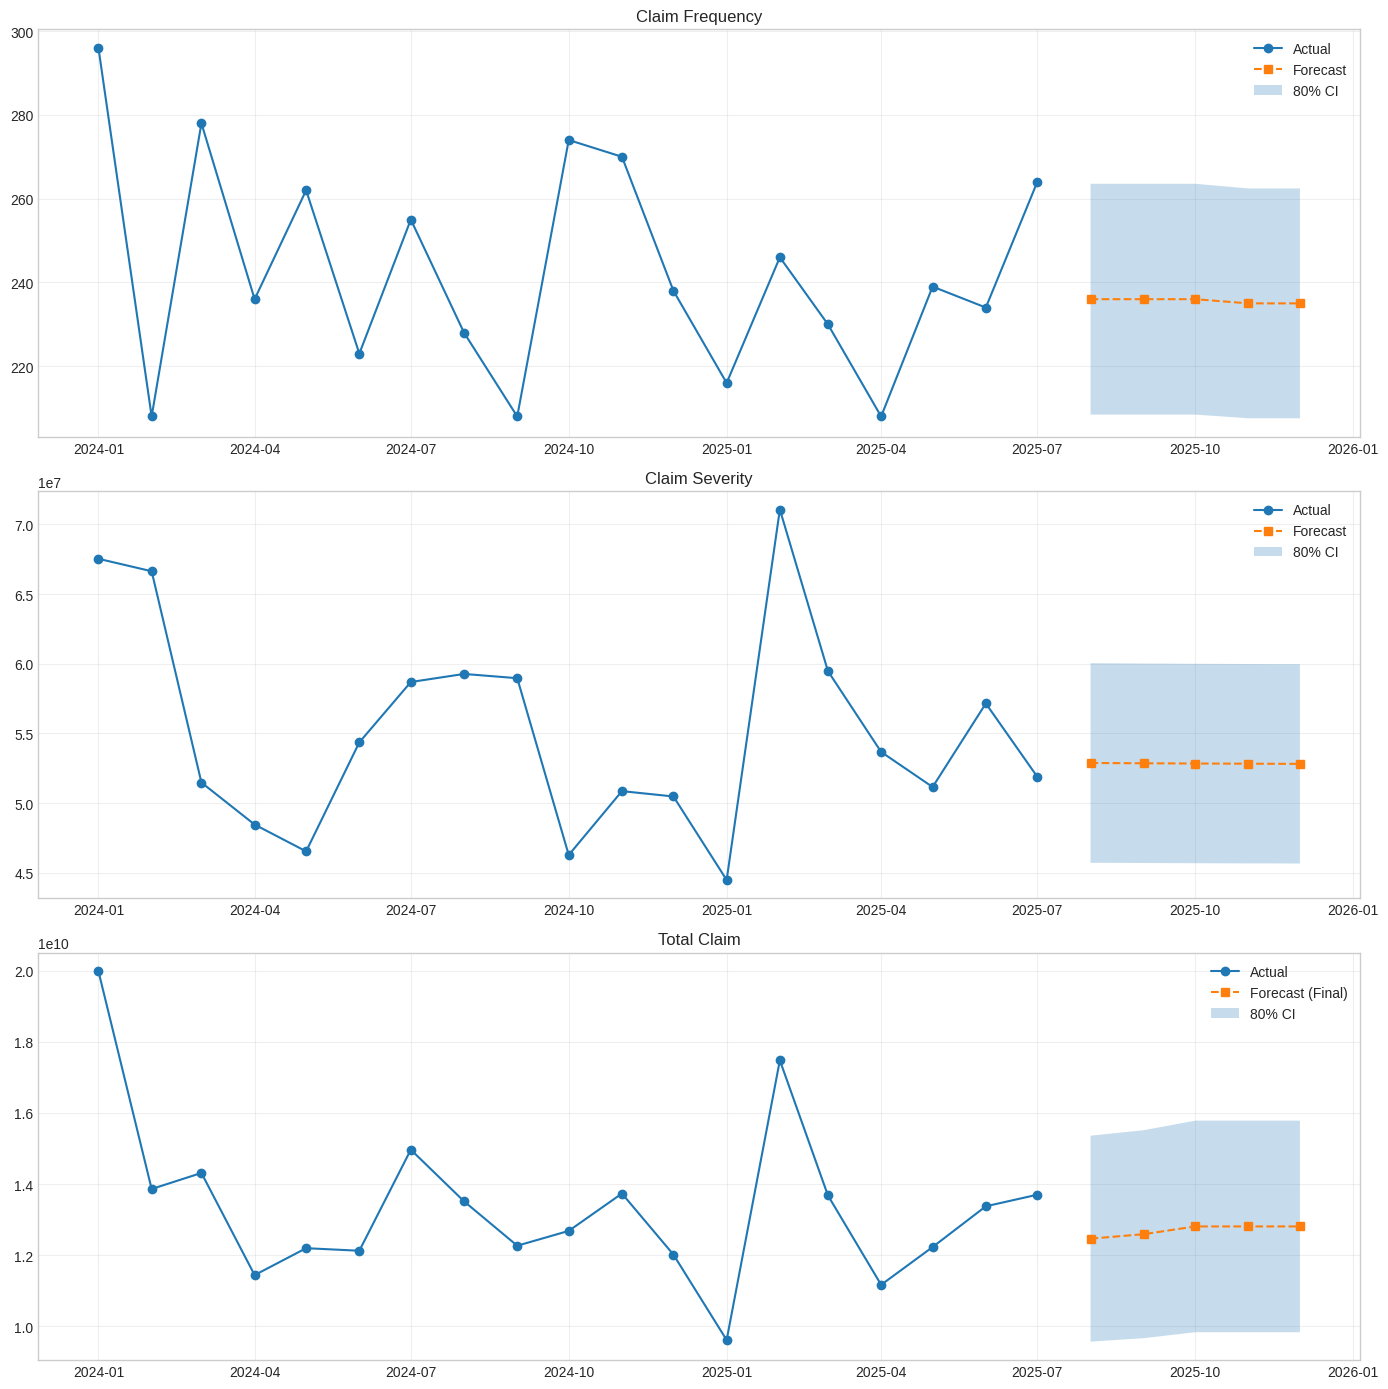

In [7]:

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=False)

axes[0].plot(monthly.index, monthly["Claim_Frequency"], marker="o", label="Actual")
axes[0].plot(FORECAST_MONTHS, freq_pred, marker="s", linestyle="--", label="Forecast")
axes[0].fill_between(FORECAST_MONTHS, freq_ci80[:, 0], freq_ci80[:, 1], alpha=0.25, label="80% CI")
axes[0].set_title("Claim Frequency")
axes[0].legend()

axes[1].plot(monthly.index, monthly["Claim_Severity"], marker="o", label="Actual")
axes[1].plot(FORECAST_MONTHS, sev_pred, marker="s", linestyle="--", label="Forecast")
axes[1].fill_between(FORECAST_MONTHS, sev_ci80[:, 0], sev_ci80[:, 1], alpha=0.25, label="80% CI")
axes[1].set_title("Claim Severity")
axes[1].legend()

axes[2].plot(monthly.index, monthly["Total_Claim"], marker="o", label="Actual")
axes[2].plot(FORECAST_MONTHS, total_final, marker="s", linestyle="--", label="Forecast (Final)")
axes[2].fill_between(FORECAST_MONTHS, tot_ci80[:, 0], tot_ci80[:, 1], alpha=0.25, label="80% CI")
axes[2].set_title("Total Claim")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 7) Optional Factor Importance (Plan Section 9)

Cell di bawah ini opsional. Jika `xgboost` tersedia, notebook akan jalankan XGBoost.
Jika tidak tersedia, fallback ke RandomForest.


Model used: XGBoost
Factor model metrics: {'MEPA': 177.66055969736647, 'MAE': 34835446.97771852, 'RMSE': 100139640.47738701, 'MdAPE': 50.69819811287361, 'Directional_Accuracy': 78.91304347826087}


,feature,importance
6,LOS,0.2617
3,Lokasi_enc,0.2383
5,IP_OP_enc,0.1373
7,RC_enc,0.1163
4,ICD_Group_enc,0.0667
2,Plan_enc,0.0429
9,quarter_num,0.0420
0,Usia,0.0399
8,month_num,0.0294
1,Gender_enc,0.0255


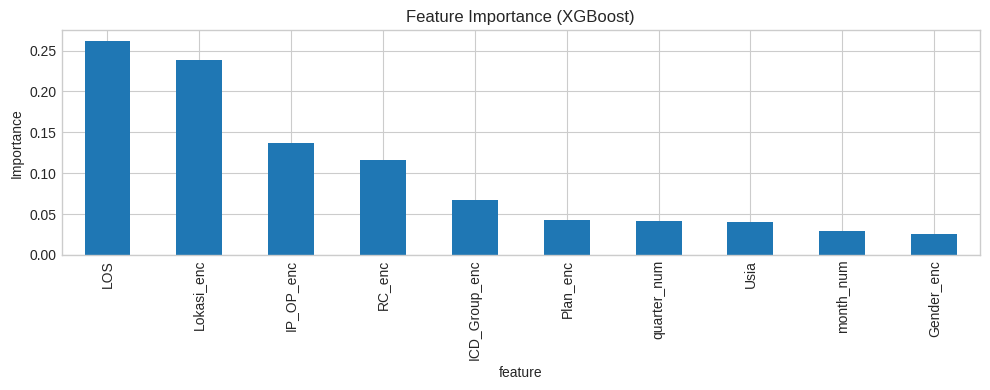

In [8]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

feature_df = claims.copy()
feature_df = feature_df[feature_df["Nominal Klaim Yang Disetujui"] > 0].copy()
feature_df["Bulan_dt"] = pd.to_datetime(feature_df["Bulan"]) 
feature_df = feature_df.sort_values("Bulan_dt")

cat_map = {
    "Gender": "Gender_enc",
    "Plan Code": "Plan_enc",
    "Lokasi RS": "Lokasi_enc",
    "ICD_Group": "ICD_Group_enc",
    "Inpatient/Outpatient": "IP_OP_enc",
    "Reimburse/Cashless": "RC_enc",
}
for col, enc in cat_map.items():
    le = LabelEncoder()
    feature_df[enc] = le.fit_transform(feature_df[col].astype(str))

feature_df["month_num"] = feature_df["Bulan_dt"].dt.month
feature_df["quarter_num"] = feature_df["Bulan_dt"].dt.quarter

feature_cols = [
    "Usia", "Gender_enc", "Plan_enc", "Lokasi_enc", "ICD_Group_enc",
    "IP_OP_enc", "LOS", "RC_enc", "month_num", "quarter_num"
]
X = feature_df[feature_cols]
y = np.log1p(feature_df["Nominal Klaim Yang Disetujui"])

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model_name = "RandomForest"
try:
    from xgboost import XGBRegressor
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        verbosity=0,
    )
    model_name = "XGBoost"
except Exception:
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        random_state=42,
        n_jobs=2,
    )

model.fit(X_train, y_train)
y_hat = model.predict(X_test)

metrics_factor = evaluate_metrics(np.expm1(y_test), np.expm1(y_hat))
print(f"Model used: {model_name}")
print("Factor model metrics:", metrics_factor)

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importances)

ax = importances.plot(kind="bar", x="feature", y="importance", figsize=(10, 4), legend=False)
ax.set_title(f"Feature Importance ({model_name})")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()
